In [1]:
import os

subj = "Subj1"

match subj:
    case 'Subj1':
        N_STAGES = 9
    case 'Subj2':
        N_STAGES = 8
    case 'Subj3':
        N_STAGES = 10

exp = "exp_dimensionality"
os.makedirs(f"{subj}/{exp}", exist_ok = True)

N_COMPONENTS = [3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 200, 300, 400, 500, 600, 700]

In [2]:
import mne
import numpy
import pandas
import sklearn.preprocessing
import sklearn.decomposition
import matplotlib.pyplot as plt

import SDA.analytics

In [3]:
def read_traditional():
    df_ft_psd_loc_db = pandas.read_feather(f'{subj}/src/df_ft_psd_loc_db.feather')
    df_ft_psd_ind_loc_log = pandas.read_feather(f'{subj}/src/df_ft_psd_ind_loc_log.feather')
    df_ft_coh_ind_loc = pandas.read_feather(f'{subj}/src/df_ft_coh_ind_loc.feather')
    df_ft_plv_ind_loc = pandas.read_feather(f'{subj}/src/df_ft_plv_ind_loc.feather')

    result =  pandas.concat([
        df_ft_psd_loc_db,
        df_ft_psd_ind_loc_log,
        df_ft_coh_ind_loc,
        df_ft_plv_ind_loc
    ], axis = 1)

    if subj == "Subj2":
        result = result[:-2]
    return result

epochs = mne.read_epochs(f"{subj}/src/epochs_filt_rr-epo.fif").drop_channels(ch_names = [ "A1", "A2" ])
if subj == "Subj2": # m8 (artifacts at the end)
    epochs = epochs[:-2]
data = epochs.get_data(copy = True)

original_traditional = read_traditional()
original_topological = pandas.read_feather(f"{subj}/exp_full_flow/features/features.feather")
original_qsda = pandas.read_feather(f"{subj}/exp_full_flow/qsda/best_features.feather")
original_combined = pandas.concat([ original_traditional, original_qsda ], axis = 1)

noise_qsda = numpy.load(f"{subj}/exp_noise/qsda/best_features.npy")
if subj == "Subj2":
    noise_qsda = noise_qsda[:-2]

shuffle_order = numpy.load(f"{subj}/exp_shuffled/shuffle_order.npy")
shuffle_order = shuffle_order[shuffle_order < len(epochs)]
shuffled_traditional = original_traditional.to_numpy()[shuffle_order]
shuffled_qsda = numpy.load(f"{subj}/exp_shuffled/qsda/best_features.npy")
if subj == "Subj2":
    shuffled_qsda = shuffled_qsda[:-2]
shuffled_combined = numpy.concatenate([ shuffled_traditional, shuffled_qsda ], axis = 1)

Reading d:\TopoEEG\Subj1\src\epochs_filt_rr-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
1046 matching events found
No baseline correction applied
0 projection items activated


In [4]:
def analyze(all_features: pandas.DataFrame, n_components: int, folder: str):
    folder = f"{subj}/{exp}/{folder}/{n_components}"
    if os.path.exists(f"{folder}/stats.svg"):
        return
    os.makedirs(folder, exist_ok = True)

    # Scale features
    all_features = sklearn.preprocessing.StandardScaler().fit_transform(all_features)
    numpy.save(f"{folder}/all_features.npy", all_features)
    numpy.savetxt(f"{folder}/all_features_shape.txt", all_features.shape)

    # PCA
    pca = sklearn.decomposition.PCA(n_components = n_components, svd_solver = "full", random_state = 42)
    pca_features = pca.fit_transform(all_features)
    numpy.save(f"{folder}/pca_features.npy", pca_features)
    numpy.savetxt(f"{folder}/pca_features_shape.txt", pca_features.shape)
    
    numpy.savetxt(f"{folder}/explained_variance.txt", [ pca.explained_variance_ratio_.sum() ])
    numpy.savetxt(f"{folder}/explained_variance_ratios.txt", pca.explained_variance_ratio_)

    # SDA
    sda = SDA.SDA(n_jobs = -1, scale = False, verbose = False)
    results, df_st_edges = sda.apply(pca_features)
    
    results.to_csv(f"{folder}/results.csv")
    df_st_edges.to_csv(f"{folder}/df_st_edges.csv")

    # Analyze
    best_results = SDA.analytics.best_results(results, key = 'Avg-Silh')
    best_results.to_csv(f"{folder}/best_results.csv")
    
    best_result = SDA.analytics.best_result(results, key = 'Avg-Silh', n_stages = N_STAGES)
    best_result_df = pandas.DataFrame([ best_result ])
    best_result_df.to_csv(f"{folder}/best_result.csv")
    
    best_edges = numpy.array(best_result['St_edges'])
    numpy.savetxt(f"{folder}/best_edges.txt", best_edges, fmt = "%d", newline = ' ')

    stage_timing = SDA.analytics.stage_timing(best_edges, epochs)
    stage_timing.to_csv(f"{folder}/stage_timing.csv")
    
    SDA.analytics.plot_stats(pca_features, epochs, best_result, df_st_edges).savefig(f"{folder}/stats.svg")

In [64]:
import tqdm

for n_components in tqdm.tqdm(N_COMPONENTS):
    analyze(original_traditional, n_components, "original_traditional")
    analyze(original_topological, n_components, "original_topological")
    analyze(original_qsda, n_components, "original_qsda")
    analyze(original_combined, n_components, "original_combined")
    analyze(noise_qsda, n_components, "noise_qsda")
    analyze(shuffled_traditional, n_components, "shuffled_traditional")
    analyze(shuffled_qsda, n_components, "shuffled_qsda")
    analyze(shuffled_combined, n_components, "shuffled_combined")

100%|██████████| 16/16 [00:00<00:00, 5007.00it/s]


### Aggregate

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


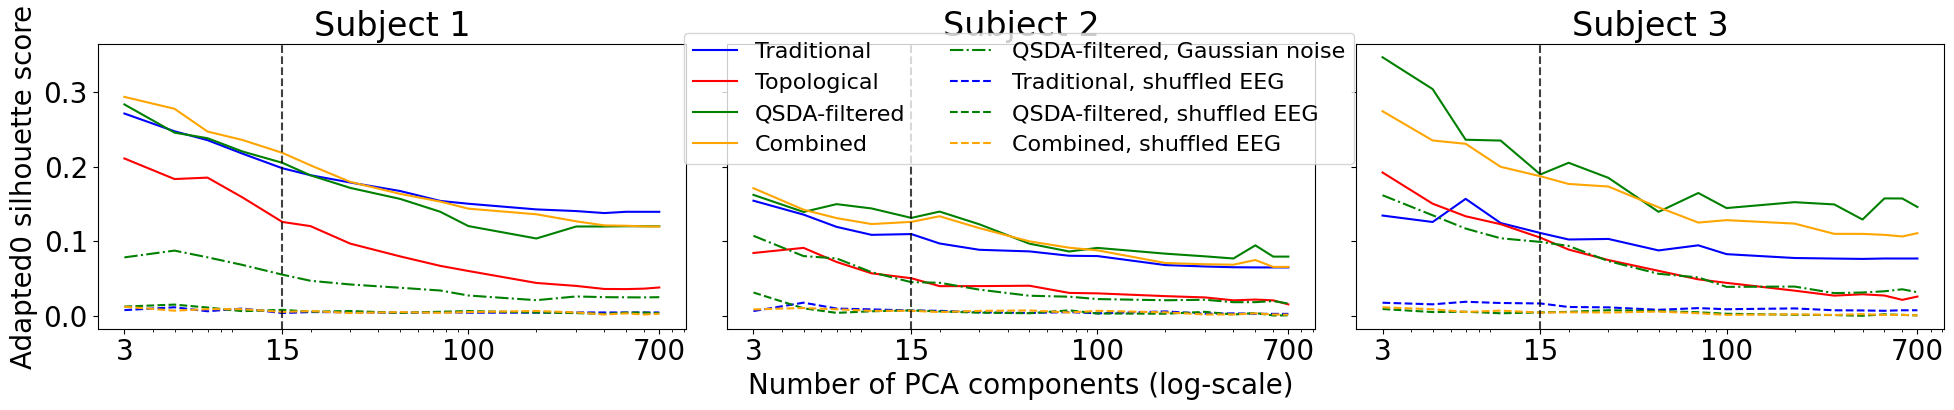

In [9]:
def plot_one(subj, ax, title):
    def read_silh(folder: str):
        return [
            pandas.read_csv(f"{subj}/{exp}/{folder}/{n_components}/best_result.csv")["Avg-Silh"].iloc[0]
            for n_components in N_COMPONENTS
        ]

    folders = [
        ("original_traditional", "Traditional",                   'blue',   None),
        ("original_topological", "Topological",                   'red',    None),
        ("original_qsda",        "QSDA-filtered",                 'green',  None),
        ("original_combined",    "Combined",                      'orange', None),
        ("noise_qsda",           "QSDA-filtered, Gaussian noise", 'green',  'dashdot'),
        ("shuffled_traditional", "Traditional, shuffled EEG",     'blue',   'dashed'),
        ("shuffled_qsda",        "QSDA-filtered, shuffled EEG",   'green',  'dashed'),
        ("shuffled_combined",    "Combined, shuffled EEG",        'orange', 'dashed')
    ]

    for folder, label, color, linestyle in folders:
        ax.plot(N_COMPONENTS, read_silh(folder), label = label, color = color, linestyle = linestyle)
    ax.axvline(15, linestyle='dashed', color='black', alpha=0.75)
    ax.set_xscale('log')
    ax.set_xticks([3, 15, 100, 700], ['3', '15', '100', '700'])
    ax.set_title(title)

plt.rc('font', size = 20)
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(20, 4.5))
plot_one("Subj1", axes[0], "Subject 1")
plot_one("Subj2", axes[1], "Subject 2")
plot_one("Subj3", axes[2], "Subject 3")

handles, labels = plt.gca().get_legend_handles_labels()
legend = fig.legend(handles, labels, loc=(0.35, 0.6), fontsize=16, ncol=2)
plt.setp(legend.get_title(), fontsize=18)
axes[0].set_ylabel("Adapted0 silhouette score")
axes[1].set_xlabel("Number of PCA components (log-scale)")

plt.tight_layout()
plt.savefig(f"article_exp_dimensionality.eps")
plt.savefig(f"article_exp_dimensionality.svg")
# plt.savefig(f"article_exp_dimensionality.png")